In [1]:
# Libraries for data handling and text preprocessing
import pandas as pd
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


In [2]:
# Download resources needed for stopwords, tokenization, and lemmatization
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download("punkt_tab")



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Load the SMS Spam dataset (tab-separated file)
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "text"]
)

df.head()


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# View a sample SMS before preprocessing
print("Before preprocessing:\n")
print(df["text"].iloc[0])


Before preprocessing:

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [5]:
# Stopwords removal reduces noise (common words usually don't help classification)
stop_words = set(stopwords.words("english"))

# Lemmatizer converts words to base form (e.g., "running" -> "run")
lemmatizer = WordNetLemmatizer()


In [6]:
# Lowercasing makes words uniform (Free == free)
df["cleaned_text"] = df["text"].str.lower()

# Removing numbers: numbers often don't help for spam/ham prediction in basic ML models
df["cleaned_text"] = df["cleaned_text"].apply(lambda x: re.sub(r"\d+", "", x))

# Removing punctuation: keeps only words, reduces noise for vectorizers like TF-IDF
df["cleaned_text"] = df["cleaned_text"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)


In [7]:
# Tokenization splits text into words (needed before stopword removal and lemmatization)
df["cleaned_text"] = df["cleaned_text"].apply(word_tokenize)

# Remove stopwords to keep meaningful words only
df["cleaned_text"] = df["cleaned_text"].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

# Lemmatize to normalize word forms (plays, played -> play)
df["cleaned_text"] = df["cleaned_text"].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

# Join tokens back into a single cleaned sentence (ready for TF-IDF / CountVectorizer)
df["cleaned_text"] = df["cleaned_text"].apply(lambda tokens: " ".join(tokens))


In [8]:
print("After preprocessing:\n")
print(df["cleaned_text"].iloc[0])

print("\n" + "-"*50 + "\n")

print("BEFORE:\n", df["text"].iloc[0])
print("\nAFTER:\n", df["cleaned_text"].iloc[0])


After preprocessing:

go jurong point crazy available bugis n great world la e buffet cine got amore wat

--------------------------------------------------

BEFORE:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

AFTER:
 go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [9]:
# Message length is often useful in spam detection
# Spam messages tend to be longer than normal (ham) messages

df["text_length"] = df["text"].apply(len)
df["cleaned_length"] = df["cleaned_text"].apply(len)


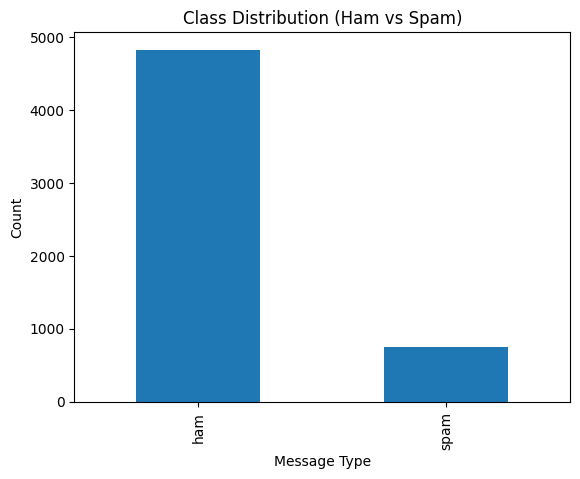

In [10]:
# This plot shows class imbalance in the dataset
# Important to understand before training ML models

import matplotlib.pyplot as plt

plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Ham vs Spam)")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()


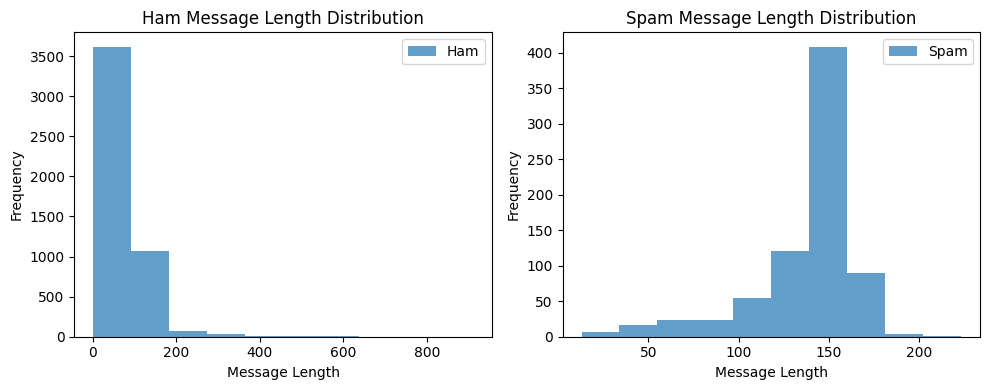

In [11]:
# This visualization compares the distribution of original message lengths
# Ham and spam are shown in separate plots for clear comparison

plt.figure(figsize=(10, 4))

# Ham messages
plt.subplot(1, 2, 1)
plt.hist(df[df["label"] == "ham"]["text_length"], alpha=0.7, label="Ham")
plt.title("Ham Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.legend()

# Spam messages
plt.subplot(1, 2, 2)
plt.hist(df[df["label"] == "spam"]["text_length"], alpha=0.7, label="Spam")
plt.title("Spam Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()



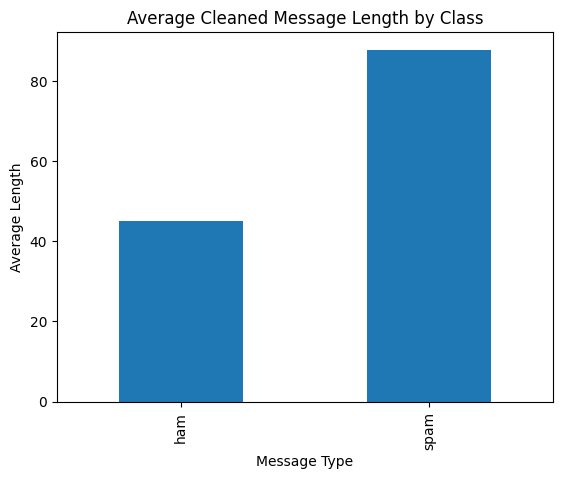

In [12]:
# This plot summarizes length differences numerically
# Spam usually has higher average length

plt.figure()
df.groupby("label")["cleaned_length"].mean().plot(kind="bar")
plt.title("Average Cleaned Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Average Length")
plt.show()


<Figure size 640x480 with 0 Axes>

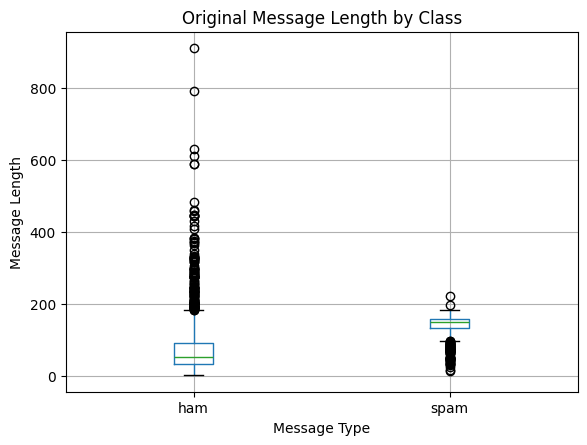

In [13]:
# A box plot shows median, spread, and outliers
# This helps us compare how long ham and spam messages are before preprocessing

plt.figure()
df.boxplot(column="text_length", by="label")
plt.title("Original Message Length by Class")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("Message Type")
plt.ylabel("Message Length")
plt.show()


In [14]:
# cleaned_text will be used as input features (X)
# label is the target variable (y)

X = df["cleaned_text"]
y = df["label"]


In [15]:
# ML models work with numbers, not text labels
# ham = 0, spam = 1

y = y.map({"ham": 0, "spam": 1})


In [16]:
# Split data into training and testing sets
# stratify=y keeps the same ham/spam ratio in both sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


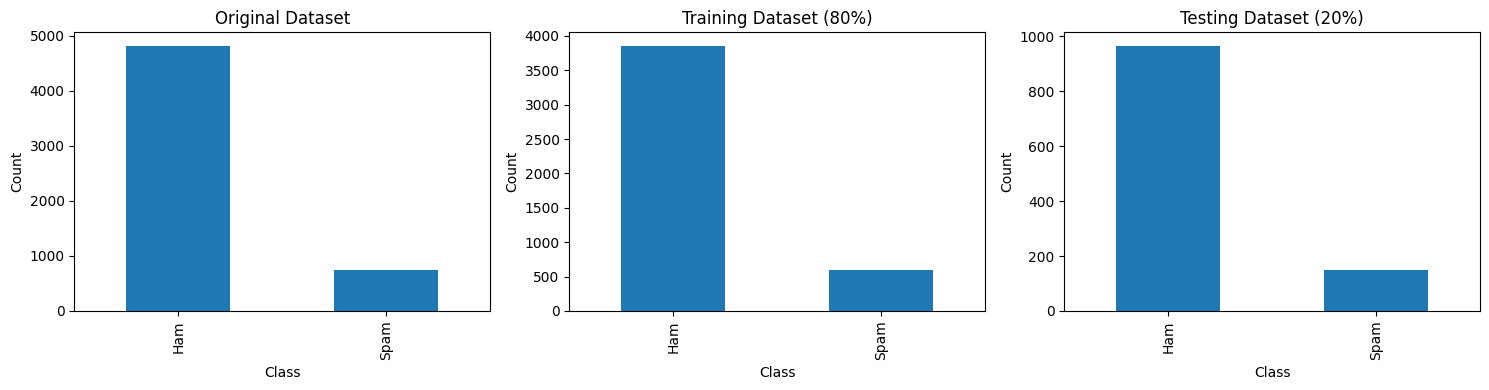

Original dataset:
Ham     4825
Spam     747
Name: count, dtype: int64

Training dataset:
Ham     3859
Spam     598
Name: count, dtype: int64

Testing dataset:
Ham     966
Spam    149
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Original dataset distribution
original_counts = df["label"].value_counts()

# Training and testing distribution
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# Rename numeric labels for readability
train_counts.index = ["Ham", "Spam"]
test_counts.index = ["Ham", "Spam"]

# Original already has text labels, make them neat
original_counts.index = ["Ham", "Spam"] if set(original_counts.index) == {"ham", "spam"} else original_counts.index

# Plot all three distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

original_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Original Dataset")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

train_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title(f"Training Dataset ({len(X_train)/len(X)*100:.0f}%)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

test_counts.plot(kind="bar", ax=axes[2])
axes[2].set_title(f"Testing Dataset ({len(X_test)/len(X)*100:.0f}%)")
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Optional: print exact counts
print("Original dataset:")
print(original_counts)
print("\nTraining dataset:")
print(train_counts)
print("\nTesting dataset:")
print(test_counts)

In [18]:
# TF-IDF converts text into numerical vectors
# It gives higher weight to important words and lower weight to common words

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,      # limits vocabulary size
    ngram_range=(1, 2)      # unigrams + bigrams
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [19]:
# Shape shows (number of samples, number of features)
# Confirms successful text vectorization

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)


Training data shape: (4457, 5000)
Testing data shape: (1115, 5000)


In [20]:
# Import SMOTE to handle class imbalance
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE with a fixed random state for reproducibility
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
# This generates synthetic samples for the minority class (spam)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

# Display class distribution before and after balancing
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_balanced))

Before SMOTE: Counter({0: 3859, 1: 598})
After SMOTE: Counter({0: 3859, 1: 3859})


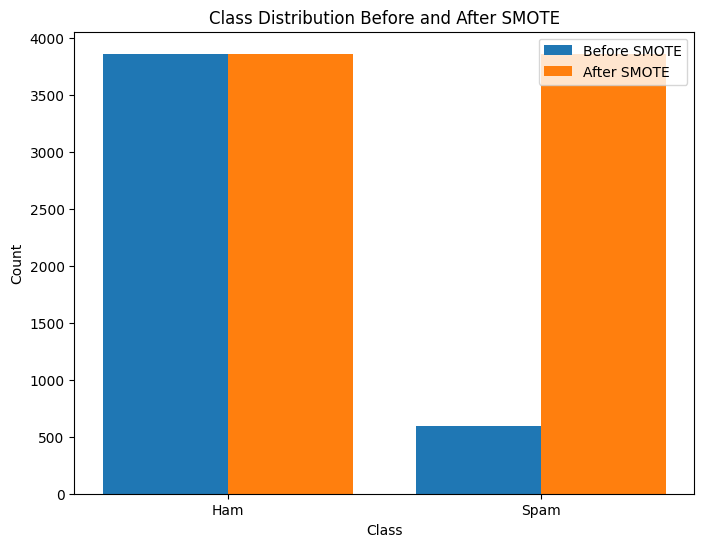

In [43]:
import matplotlib.pyplot as plt
from collections import Counter

# Get class counts
before_counts = Counter(y_train)
after_counts = Counter(y_train_balanced)

# Labels (ensure consistent order)
labels = ["Ham", "Spam"]

before_values = [before_counts[0], before_counts[1]]
after_values = [after_counts[0], after_counts[1]]

# Create side-by-side bar chart
x = range(len(labels))

plt.figure(figsize=(8, 6))

plt.bar(x, before_values, width=0.4, label="Before SMOTE")
plt.bar([i + 0.4 for i in x], after_values, width=0.4, label="After SMOTE")

# Formatting
plt.xticks([i + 0.2 for i in x], labels)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution Before and After SMOTE")
plt.legend()

plt.show()

In [21]:
# Import machine learning algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Import pandas for creating comparison tables
import pandas as pd

In [22]:
# Initialize Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using balanced training data
rf_model.fit(X_train_balanced, y_train_balanced)

# Predict labels for the test dataset
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate model performance
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9820627802690582
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [23]:
# Initialize Support Vector Classifier with linear kernel
svc_model = SVC(kernel='linear', random_state=42)

# Train the model on balanced training data
svc_model.fit(X_train_balanced, y_train_balanced)

# Predict labels for the test dataset
y_pred_svc = svc_model.predict(X_test_tfidf)

# Evaluate model performance
print("SVC Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

SVC Results
Accuracy: 0.9757847533632287
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.91      0.91      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
# Initialize XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100,       # number of boosting trees
    max_depth=6,            # maximum tree depth
    learning_rate=0.1,      # learning rate for boosting
    random_state=42,
    eval_metric='logloss'
)

# Train the model using balanced training data
xgb_model.fit(X_train_balanced, y_train_balanced)

# Predict labels for the test dataset
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Evaluate model performance
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.9623318385650225
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.89      0.82      0.85       149

    accuracy                           0.96      1115
   macro avg       0.93      0.90      0.92      1115
weighted avg       0.96      0.96      0.96      1115



In [25]:
# Create a table comparing model performance metrics
comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "SVC", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svc),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svc),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svc),
        f1_score(y_test, y_pred_xgb)
    ]
})

# Display the comparison table
comparison_table.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9821,0.9924,0.8725,0.9286
1,SVC,0.9758,0.9067,0.9128,0.9097
2,XGBoost,0.9623,0.8905,0.8188,0.8531


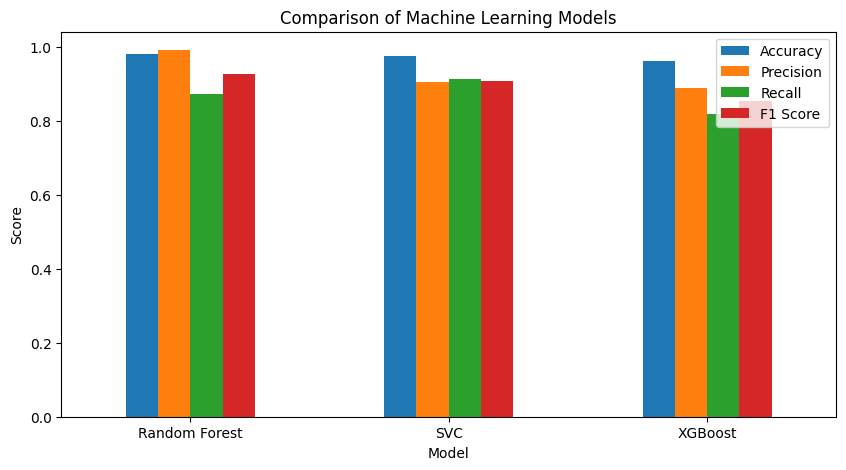

In [26]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Plot model performance comparison
comparison_table.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.show()

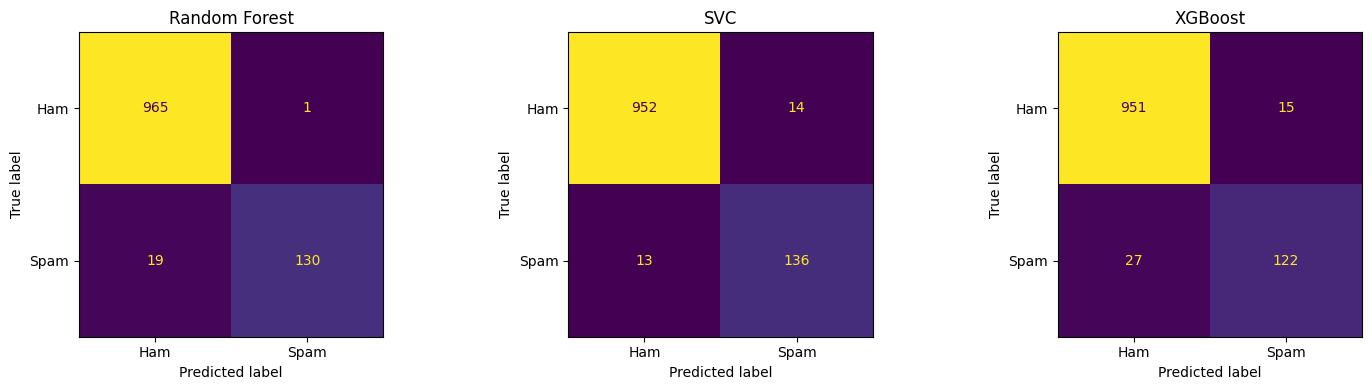

In [27]:
# Import required libraries for confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrices for each model
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15,4))

ConfusionMatrixDisplay(cm_rf, display_labels=["Ham","Spam"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(cm_svc, display_labels=["Ham","Spam"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("SVC")

ConfusionMatrixDisplay(cm_xgb, display_labels=["Ham","Spam"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()

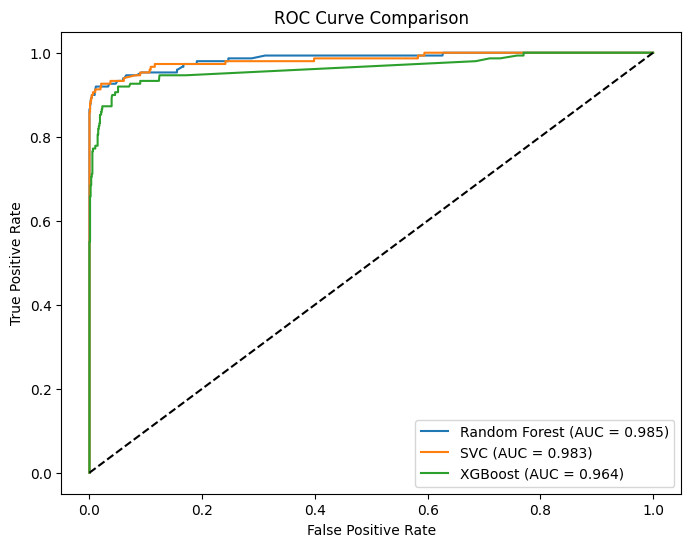

In [28]:
# Import ROC curve functions
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores for ROC curve

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test_tfidf)[:,1]

# SVC decision scores
svc_scores = svc_model.decision_function(X_test_tfidf)

# XGBoost probabilities
xgb_probs = xgb_model.predict_proba(X_test_tfidf)[:,1]

# Calculate ROC curve values
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svc, tpr_svc, _ = roc_curve(y_test, svc_scores)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# Calculate AUC scores
auc_rf = roc_auc_score(y_test, rf_probs)
auc_svc = roc_auc_score(y_test, svc_scores)
auc_xgb = roc_auc_score(y_test, xgb_probs)

# Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {auc_svc:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Diagonal reference line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [29]:
# GridSearchCV is used to test multiple hyperparameter combinations
from sklearn.model_selection import GridSearchCV

# Random Forest hyperparameter tuning
# We tune number of trees, tree depth, and split conditions

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

# Fit GridSearch on balanced training data
rf_grid.fit(X_train_balanced, y_train_balanced)

# Display best parameters and best cross-validation score
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest F1 Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest F1 Score: 0.9882299744148755


In [32]:
# SVC hyperparameter tuning
# We tune the regularization parameter C

svc_param_grid = {
    "C": [0.1, 1, 10]
}

svc_grid = GridSearchCV(
    estimator=SVC(kernel="linear", probability=True, random_state=42),
    param_grid=svc_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

svc_grid.fit(X_train_balanced, y_train_balanced)

print("Best SVC Parameters:", svc_grid.best_params_)
print("Best SVC F1 Score:", svc_grid.best_score_)

Best SVC Parameters: {'C': 1}
Best SVC F1 Score: 0.9706549932723038


In [31]:
# XGBoost hyperparameter tuning
# We tune number of trees, learning rate, and tree depth

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

# Fit GridSearch on balanced training data
xgb_grid.fit(X_train_balanced, y_train_balanced)

# Display best parameters and best cross-validation score
print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best XGBoost F1 Score:", xgb_grid.best_score_)

Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200}
Best XGBoost F1 Score: 0.978622582251532


In [40]:
y_pred_rf = best_rf.predict(X_test_tfidf)
y_pred_svc = best_svc.predict(X_test_tfidf)
y_pred_xgb = best_xgb.predict(X_test_tfidf)

In [41]:
y_prob_rf = best_rf.predict_proba(X_test_tfidf)[:, 1]
y_prob_svc = best_svc.predict_proba(X_test_tfidf)[:, 1]
y_prob_xgb = best_xgb.predict_proba(X_test_tfidf)[:, 1]

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

SVC
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.91      0.91      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115

XGBOOST
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.89      0.87      0.88       149

    accuracy                           0.97      1115
   macro avg       0.93      0.92      0.93      1115
weighted avg       0.97      0.97      0.97     

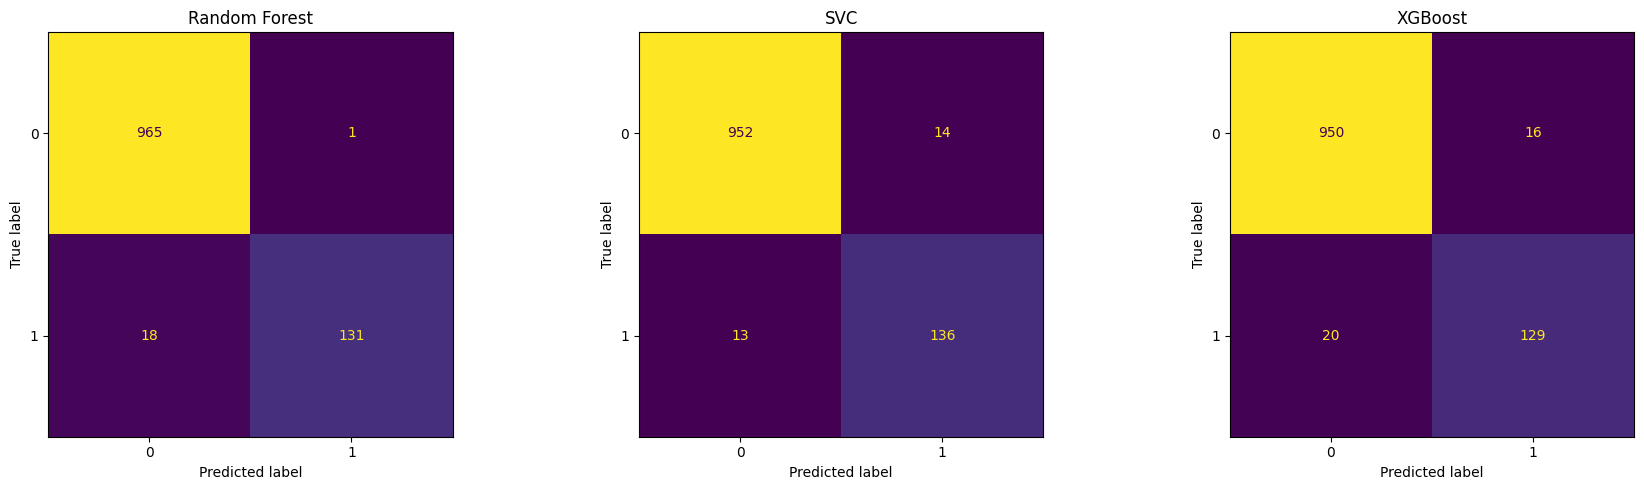

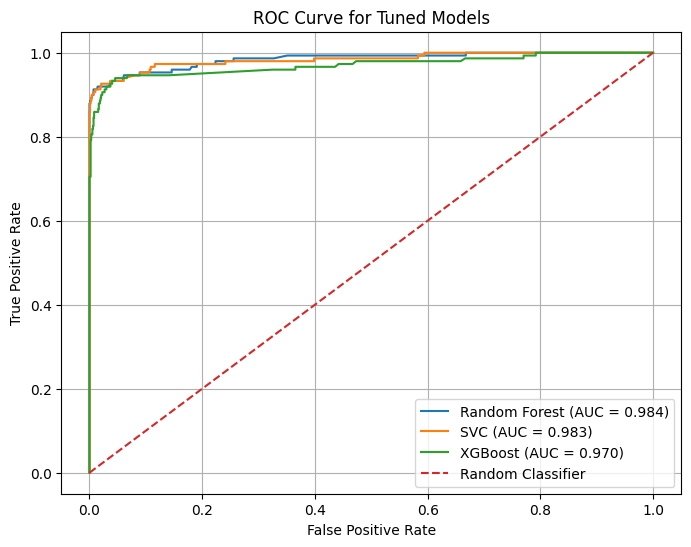

Random Forest AUC: 0.9844
SVC AUC: 0.9834
XGBoost AUC: 0.9703


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get the best tuned models
best_rf = rf_grid.best_estimator_
best_svc = svc_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# Make predictions on vectorized test data
y_pred_rf = best_rf.predict(X_test_tfidf)
y_pred_svc = best_svc.predict(X_test_tfidf)
y_pred_xgb = best_xgb.predict(X_test_tfidf)

# Print classification reports
print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

print("SVC")
print(classification_report(y_test, y_pred_svc))

print("XGBOOST")
print(classification_report(y_test, y_pred_xgb))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Random Forest", y_pred_rf),
    ("SVC", y_pred_svc),
    ("XGBoost", y_pred_xgb)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Get predicted probabilities from vectorized test data
y_prob_rf = best_rf.predict_proba(X_test_tfidf)[:, 1]
y_prob_svc = best_svc.predict_proba(X_test_tfidf)[:, 1]
y_prob_xgb = best_xgb.predict_proba(X_test_tfidf)[:, 1]

# Compute ROC curve points
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Compute AUC scores
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svc = roc_auc_score(y_test, y_prob_svc)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {auc_svc:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Tuned Models")
plt.legend()
plt.grid(True)
plt.show()

# Print AUC scores
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"SVC AUC: {auc_svc:.4f}")
print(f"XGBoost AUC: {auc_xgb:.4f}")